<a href="https://colab.research.google.com/github/kalyani-n2711/PCOS-Ultrasound-Analysis/blob/main/ques8pcos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import shutil

zip_path = '/content/drive/MyDrive/archive (5).zip'  # Path to your ZIP file
extract_to = '/content/drive/MyDrive/extracted_files'  # Destination folder

# Extract all files using shutil
shutil.unpack_archive(zip_path, extract_to)

print(f"Files extracted to {extract_to}")



Files extracted to /content/drive/MyDrive/extracted_files


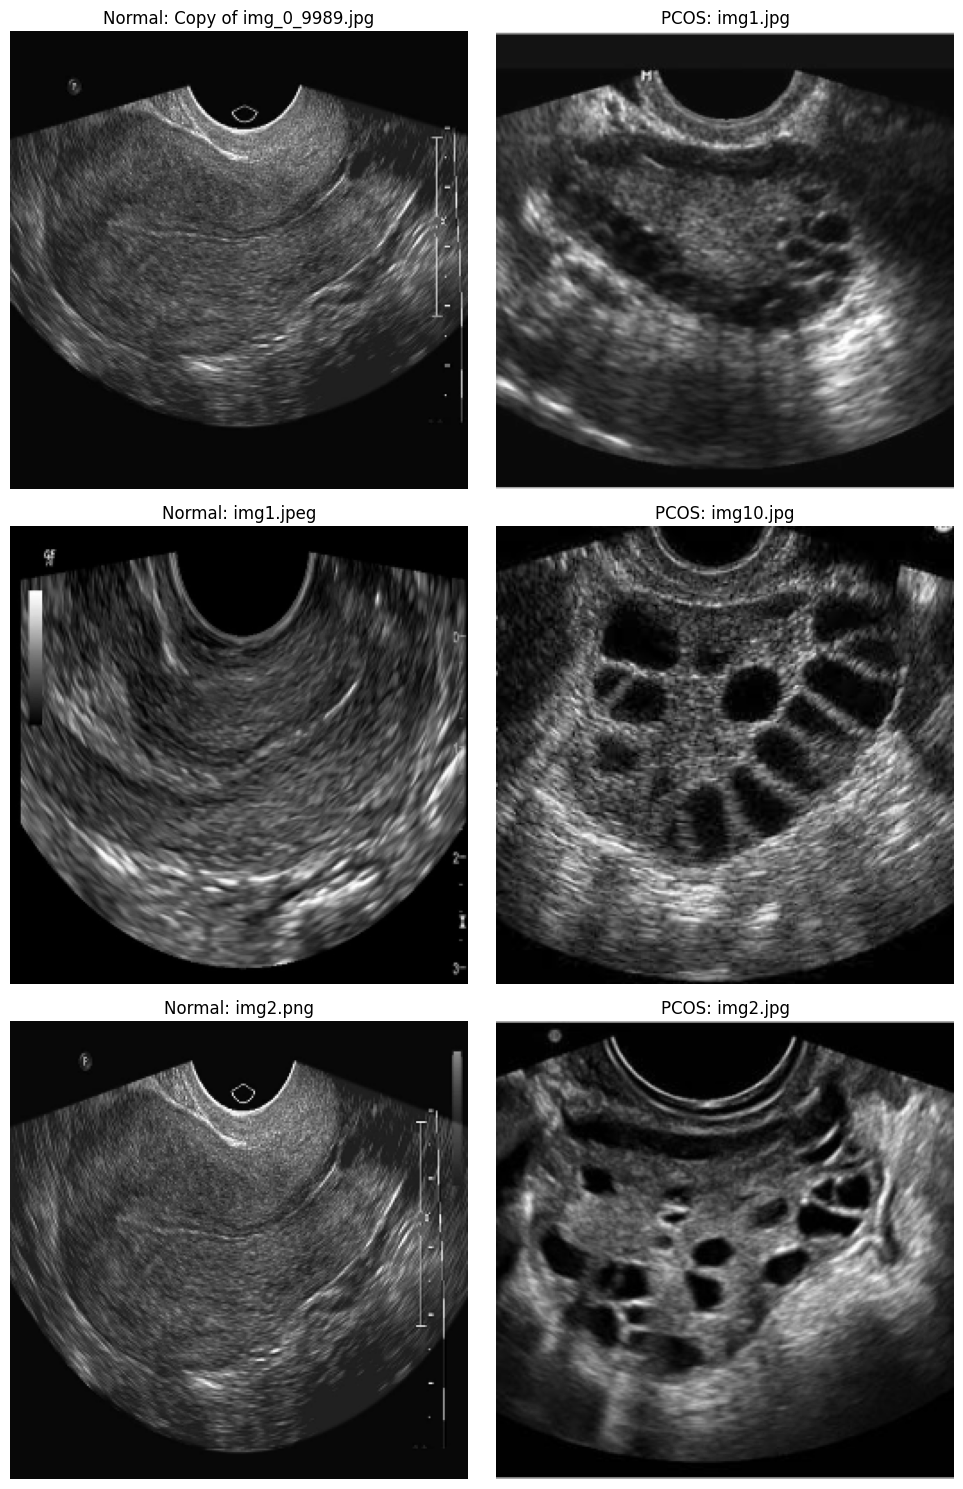

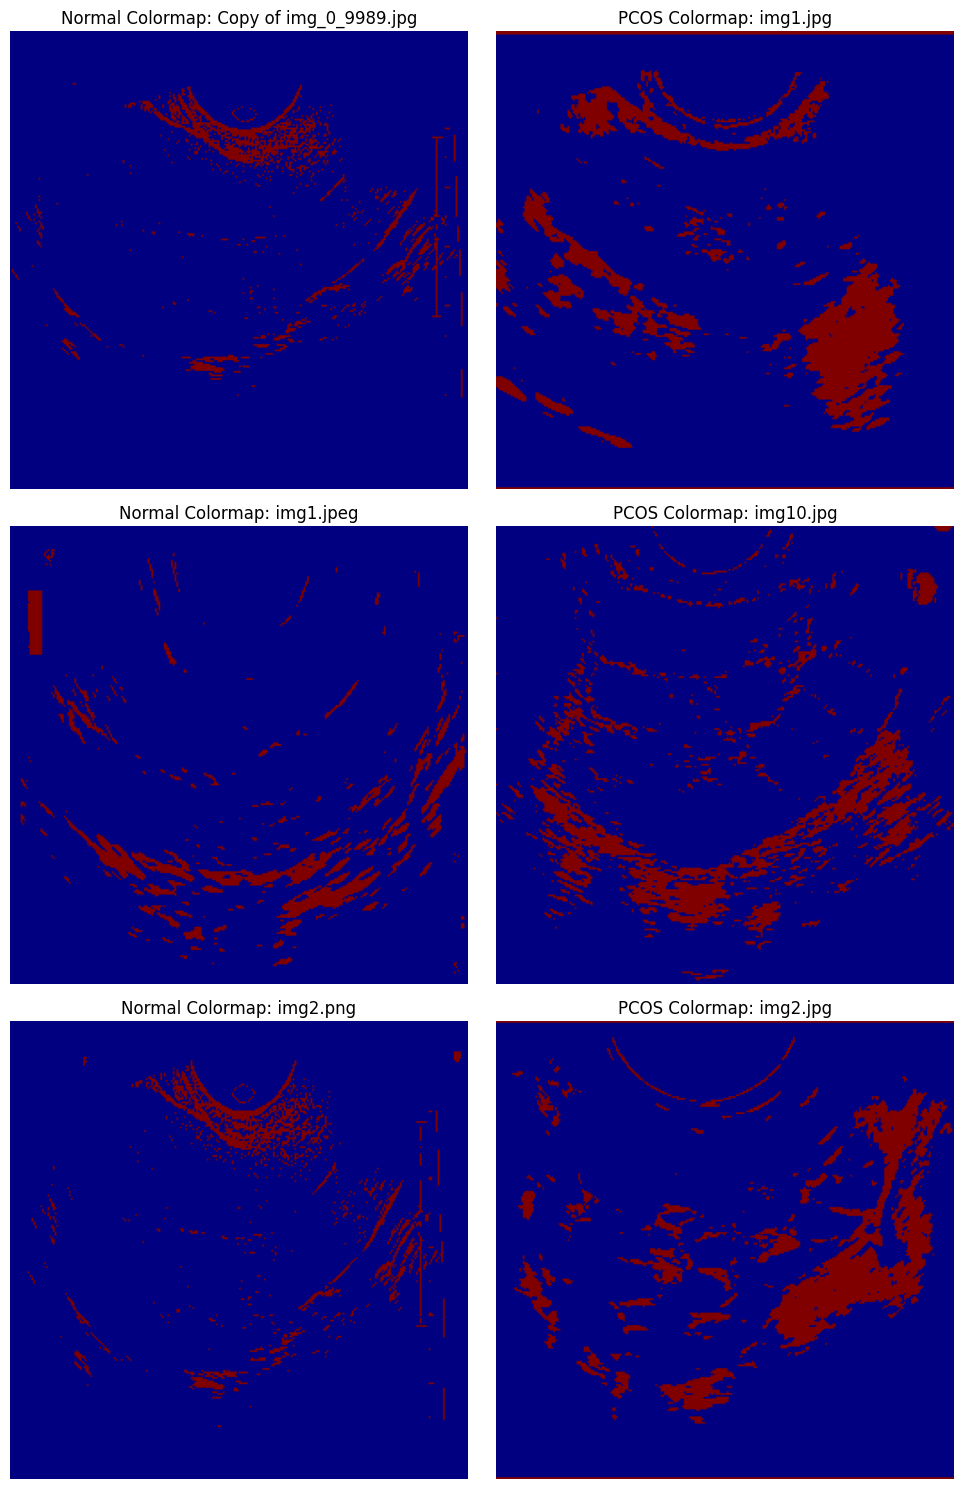

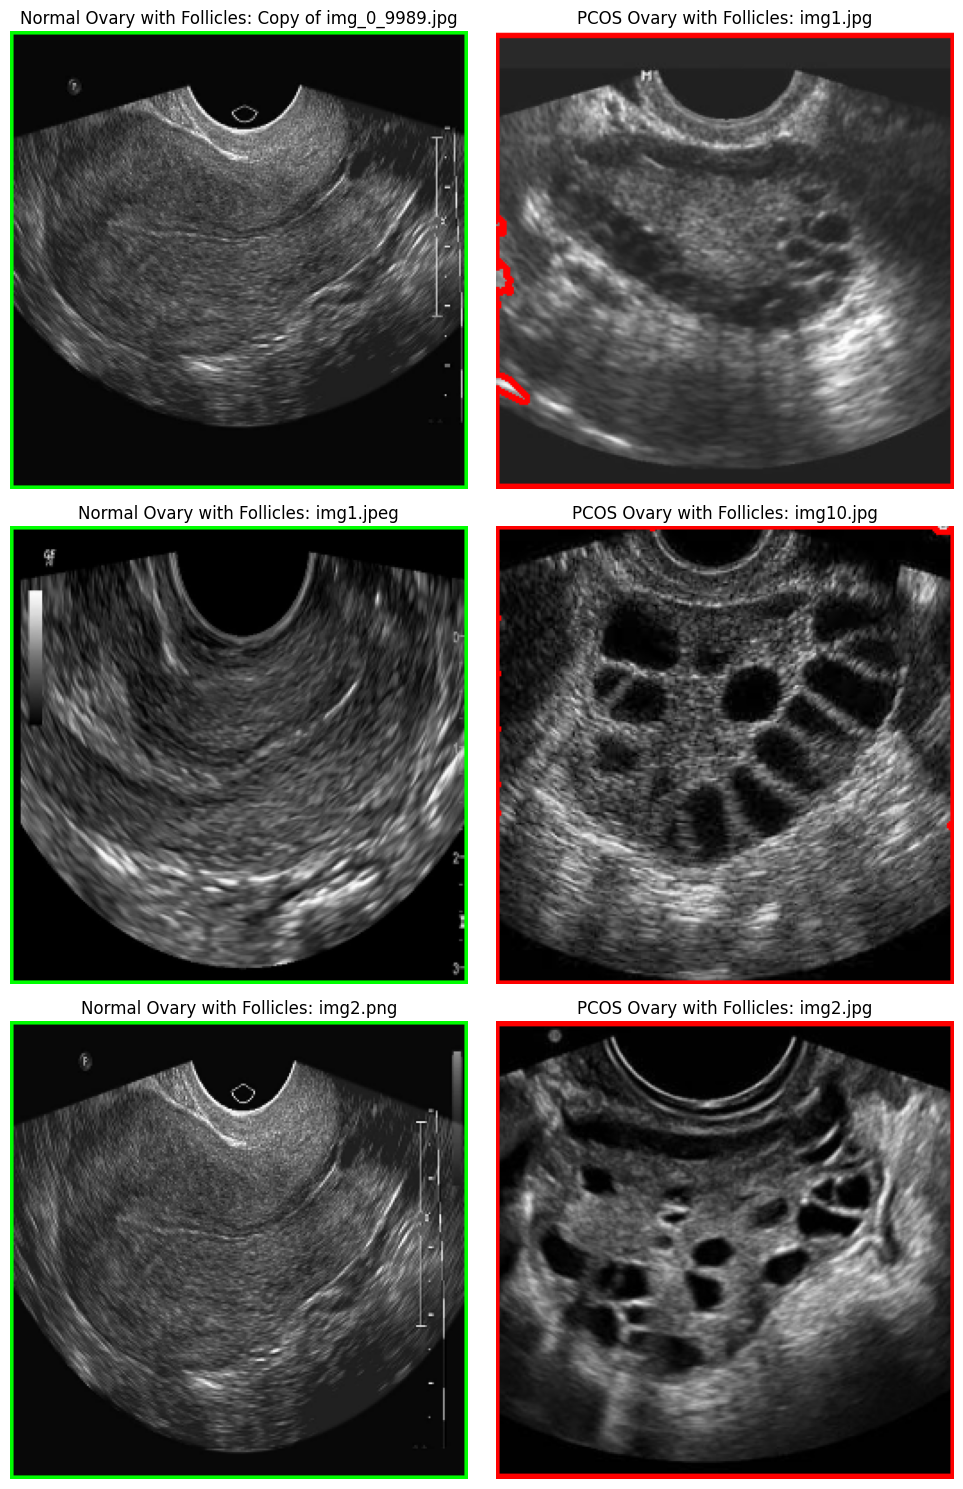

In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

class OvaryAnalysis:
    def __init__(self, normal_directory, pcos_directory, max_images=5, image_size=(256, 256)):
        self.normal_directory = normal_directory
        self.pcos_directory = pcos_directory
        self.normal_images = sorted(os.listdir(normal_directory))[:max_images]  # Limit the number of images
        self.pcos_images = sorted(os.listdir(pcos_directory))[:max_images]  # Limit the number of images
        self.image_size = image_size  # Desired image size (width, height)

    def process_image(self, image_path):
        """
        Process a single image: resize, convert to grayscale, and apply thresholding.
        """
        # Load the image
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        # Resize the image
        image = cv2.resize(image, self.image_size)

        # Threshold to detect follicles (binary image)
        _, binary_image = cv2.threshold(image, 120, 255, cv2.THRESH_BINARY_INV)

        return image, binary_image

    def compare_original_augmented(self):
        """
        Create comparison plots for original and augmented images (normal vs. PCOS).
        """
        fig, axes = plt.subplots(len(self.normal_images), 2, figsize=(10, 5 * len(self.normal_images)))

        for i in range(len(self.normal_images)):
            normal_image_path = os.path.join(self.normal_directory, self.normal_images[i])
            pcos_image_path = os.path.join(self.pcos_directory, self.pcos_images[i])

            normal_img, normal_binary = self.process_image(normal_image_path)
            pcos_img, pcos_binary = self.process_image(pcos_image_path)

            axes[i, 0].imshow(normal_img, cmap='gray')
            axes[i, 0].set_title(f"Normal: {self.normal_images[i]}")
            axes[i, 0].axis('off')

            axes[i, 1].imshow(pcos_img, cmap='gray')
            axes[i, 1].set_title(f"PCOS: {self.pcos_images[i]}")
            axes[i, 1].axis('off')

        plt.tight_layout()
        plt.show()

    def generate_colormap(self):
        """       Generate color maps to visualize differences in ovarian structures (e.g., follicles).
        """
        fig, axes = plt.subplots(len(self.normal_images), 2, figsize=(10, 5 * len(self.normal_images)))
        for i in range(len(self.normal_images)):
            normal_image_path = os.path.join(self.normal_directory, self.normal_images[i])
            pcos_image_path = os.path.join(self.pcos_directory, self.pcos_images[i])
            normal_img, normal_binary = self.process_image(normal_image_path)
            pcos_img, pcos_binary = self.process_image(pcos_image_path)
            normal_colormap = cv2.applyColorMap(normal_binary, cv2.COLORMAP_JET)
            pcos_colormap = cv2.applyColorMap(pcos_binary, cv2.COLORMAP_JET)
            axes[i, 0].imshow(normal_colormap)
            axes[i, 0].set_title(f"Normal Colormap: {self.normal_images[i]}")
            axes[i, 0].axis('off')
            axes[i, 1].imshow(pcos_colormap)
            axes[i, 1].set_title(f"PCOS Colormap: {self.pcos_images[i]}")
            axes[i, 1].axis('off')
        plt.tight_layout()
        plt.show()
    def overlay_follicles(self):
        fig, axes = plt.subplots(len(self.normal_images), 2, figsize=(10, 5 * len(self.normal_images)))
        for i in range(len(self.normal_images)):
            normal_image_path = os.path.join(self.normal_directory, self.normal_images[i])
            pcos_image_path = os.path.join(self.pcos_directory, self.pcos_images[i])
            normal_img, normal_binary = self.process_image(normal_image_path)
            pcos_img, pcos_binary = self.process_image(pcos_image_path)
            normal_contours, _ = cv2.findContours(normal_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            pcos_contours, _ = cv2.findContours(pcos_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            normal_overlay = cv2.cvtColor(normal_img, cv2.COLOR_GRAY2RGB)
            pcos_overlay = cv2.cvtColor(pcos_img, cv2.COLOR_GRAY2RGB)
            cv2.drawContours(normal_overlay, normal_contours, -1, (0, 255, 0), 2)  # Green for normal follicles
            cv2.drawContours(pcos_overlay, pcos_contours, -1, (255, 0, 0), 2)  # Blue for PCOS follicles
            axes[i, 0].imshow(normal_overlay)
            axes[i, 0].set_title(f"Normal Ovary with Follicles: {self.normal_images[i]}")
            axes[i, 0].axis('off')
            axes[i, 1].imshow(pcos_overlay)
            axes[i, 1].set_title(f"PCOS Ovary with Follicles: {self.pcos_images[i]}")
            axes[i, 1].axis('off')
        plt.tight_layout()
        plt.show()
normal_directory = '/content/drive/MyDrive/extracted_files/dataset/normal'
pcos_directory = '/content/drive/MyDrive/extracted_files/dataset/pcos'
analysis = OvaryAnalysis(normal_directory, pcos_directory, max_images=3, image_size=(256, 256))
analysis.compare_original_augmented()
analysis.generate_colormap()
analysis.overlay_follicles()
